State vector:
[1.+0.j 0.+0.j]

Bloch coordinates:
x = 0.0
y = 0.0
z = 1.0


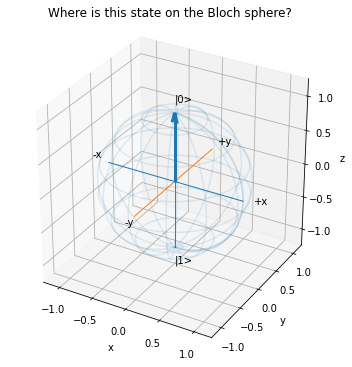


Hamiltonian:
[[ 0.5+0.j  0.5+0.j]
 [ 0.5+0.j -0.5+0.j]]


In [1]:
"""
Single-Qubit QuTiP Workshop Exercises
-------------------------------------
Goal: learn how a one-qubit state appears on the Bloch sphere and how a
2x2 Hamiltonian moves it.

Run in a notebook/cell-by-cell environment if possible.
Requires: numpy, matplotlib, qutip
Install if needed: pip install qutip matplotlib numpy
"""

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0) Basic qubit objects
# ============================================================

# Computational basis states
#
# |0> = [1, 0]^T
# |1> = [0, 1]^T
#
# These are the two basis states of a qubit.

zero = np.array([1, 0], dtype=complex)
one  = np.array([0, 1], dtype=complex)


# Pauli matrices
#
# sigma_x mixes |0> and |1>
# sigma_y also mixes them, but with a phase
# sigma_z distinguishes |0> and |1>

sx = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sy = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sz = np.array([
    [1,  0],
    [0, -1]
], dtype=complex)


# ============================================================
# 1) Make a qubit state from Bloch-sphere angles
# ============================================================

def state_from_angles(theta, phi):
    """
    Construct a qubit state

        |psi> = cos(theta/2)|0>
              + exp(i phi) sin(theta/2)|1>

    theta controls how far we move from the north pole.
    phi controls the angle around the equator.
    """

    psi = (
        np.cos(theta / 2) * zero
        + np.exp(1j * phi) * np.sin(theta / 2) * one
    )

    return psi


# Try some familiar states.

psi = state_from_angles(0, 0)                 # |0>
# psi = state_from_angles(np.pi, 0)           # |1>
# psi = state_from_angles(np.pi / 2, 0)       # +x
# psi = state_from_angles(np.pi / 2, np.pi)   # -x
# psi = state_from_angles(np.pi / 2, np.pi/2) # +y


print("State vector:")
print(psi)


# ============================================================
# 2) Expectation values and Bloch coordinates
# ============================================================

def expect(operator, psi):
    """
    Compute <psi| A |psi>.
    """

    value = np.vdot(psi, operator @ psi)

    # Expectation values of the Pauli matrices should be real.
    return np.real_if_close(value).real


def bloch_coordinates(psi):
    """
    A pure qubit state corresponds to a point (x,y,z)
    on the Bloch sphere:

        x = <sigma_x>
        y = <sigma_y>
        z = <sigma_z>
    """

    x = expect(sx, psi)
    y = expect(sy, psi)
    z = expect(sz, psi)

    return np.array([x, y, z])


x, y, z = bloch_coordinates(psi)

print("\nBloch coordinates:")
print("x =", x)
print("y =", y)
print("z =", z)


# ============================================================
# 3) Plot a single state on the Bloch sphere
# ============================================================

def setup_bloch_sphere(ax):
    """
    Draw a simple Bloch sphere using Matplotlib.
    """

    # Sphere surface
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 30)

    X = np.outer(np.cos(u), np.sin(v))
    Y = np.outer(np.sin(u), np.sin(v))
    Z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(
        X, Y, Z,
        rstride=4,
        cstride=4,
        alpha=0.12
    )

    # Coordinate axes
    ax.plot([-1, 1], [0, 0], [0, 0], linewidth=1)
    ax.plot([0, 0], [-1, 1], [0, 0], linewidth=1)
    ax.plot([0, 0], [0, 0], [-1, 1], linewidth=1)

    # Labels
    ax.text(1.15, 0, 0, "+x")
    ax.text(-1.25, 0, 0, "-x")

    ax.text(0, 1.15, 0, "+y")
    ax.text(0, -1.25, 0, "-y")

    ax.text(0, 0, 1.15, "|0>")
    ax.text(0, 0, -1.25, "|1>")

    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])

    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")


def show_bloch_state(psi, title="Qubit state"):
    """
    Plot one qubit state as a vector on the Bloch sphere.
    """

    x, y, z = bloch_coordinates(psi)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    setup_bloch_sphere(ax)

    # Draw state vector
    ax.quiver(
        0, 0, 0,
        x, y, z,
        linewidth=3,
        arrow_length_ratio=0.15
    )

    ax.set_title(title)

    plt.show()


show_bloch_state(psi, title="Where is this state on the Bloch sphere?")


# ============================================================
# Try it yourself
# ============================================================

# Change theta and phi.
#
# What state do you obtain?
#
# theta = 0
#
# theta = pi
#
# theta = pi/2, phi = 0
#
# theta = pi/2, phi = pi/2
#
#
# QUESTION:
# What does changing theta do?
#
# QUESTION:
# What does changing phi do?


# ============================================================
# 4) Hamiltonian
# ============================================================

def hamiltonian(Delta, Omega):
    """
    Construct the 2x2 Hamiltonian

                  Delta/2      Omega/2
        H =      ---------------------
                  Omega/2     -Delta/2


    Equivalently:

        H = (Delta/2) sigma_z
          + (Omega/2) sigma_x


    Delta:
        diagonal part
        -> changes relative phase
        -> rotation around z

    Omega:
        off-diagonal part
        -> mixes |0> and |1>
        -> rotation around x
    """

    H = np.array([
        [ Delta / 2,  Omega / 2],
        [ Omega / 2, -Delta / 2]
    ], dtype=complex)

    return H


# First try BOTH terms.
Delta = 1.0
Omega = 1.0

H = hamiltonian(Delta, Omega)

print("\nHamiltonian:")
print(H)


# ============================================================
# Things to try
# ============================================================

# CASE A:
#
# Delta = 1
# Omega = 0
#
# What is special about this Hamiltonian?
# Is it diagonal?


# CASE B:
#
# Delta = 0
# Omega = 1
#
# What is special now?
# The Hamiltonian has only off-diagonal terms.


# CASE C:
#
# Delta = 1
# Omega = 1
#
# What do you expect when both are present?


# ============================================================
# 5) Time evolution
# ============================================================

def evolve(H, psi0, t):
    """
    Evolve a state using

        |psi(t)> = exp(-i H t) |psi(0)>

    We diagonalize H to calculate the matrix exponential.
    """

    # Eigenvalues and eigenvectors
    energies, vectors = np.linalg.eigh(H)

    # Time evolution in the energy basis
    U_energy = np.diag(np.exp(-1j * energies * t))

    # Transform back to our original basis
    U = vectors @ U_energy @ vectors.conj().T

    return U @ psi0


def run_dynamics(psi0, H, tmax=10, nt=300):
    """
    Evolve the state for many times and calculate
    its Bloch coordinates.
    """

    tlist = np.linspace(0, tmax, nt)

    x = []
    y = []
    z = []

    for t in tlist:

        psi_t = evolve(H, psi0, t)

        xi, yi, zi = bloch_coordinates(psi_t)

        x.append(xi)
        y.append(yi)
        z.append(zi)

    return (
        tlist,
        np.array(x),
        np.array(y),
        np.array(z)
    )




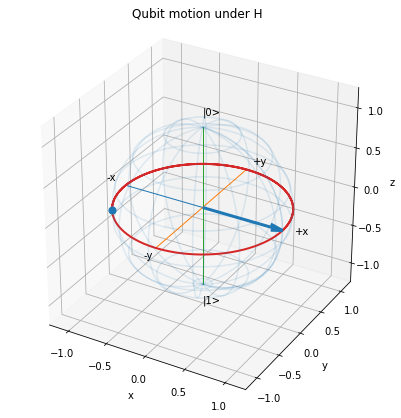

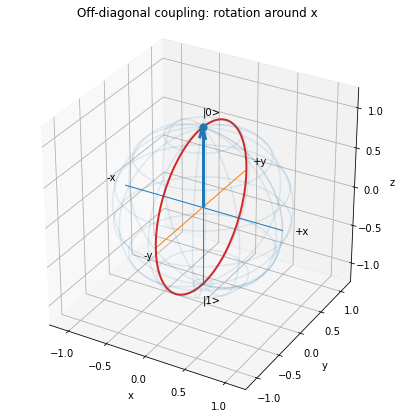

In [2]:
# ============================================================
# 6) First dynamics experiment
# ============================================================

# Start from the +x state.
#
# Why might +x be useful if we want to see
# what a DIAGONAL Hamiltonian does?

psi0 = state_from_angles(np.pi / 2, 0)  # +x state

# psi0 = zero
# Uncomment this instead if you want to start at |0>.


# Try a purely diagonal Hamiltonian first.

Delta = 1.0
Omega = 0.0

H = hamiltonian(Delta, Omega)

tlist, x, y, z = run_dynamics(
    psi0,
    H,
    tmax=10,
    nt=300
)


# ============================================================
# 7) Show a trajectory on the Bloch sphere
# ============================================================

def show_bloch_trajectory(
    x,
    y,
    z,
    title="Trajectory on the Bloch sphere"
):
    """
    Plot a trajectory from x(t), y(t), z(t)
    on the Bloch sphere.
    """

    fig = plt.figure(figsize=(7, 7))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    setup_bloch_sphere(ax)

    # Full trajectory
    ax.plot(
        x,
        y,
        z,
        linewidth=2
    )

    # Initial vector
    ax.quiver(
        0, 0, 0,
        x[0], y[0], z[0],
        linewidth=3,
        arrow_length_ratio=0.15
    )

    # Final position
    ax.scatter(
        x[-1],
        y[-1],
        z[-1],
        s=50
    )

    ax.set_title(title)

    plt.show()


show_bloch_trajectory(
    x,
    y,
    z,
    title="Qubit motion under H"
)


# ============================================================
# QUESTION
# ============================================================

# Here:
#
# Delta = 1
# Omega = 0
#
# H is diagonal.
#
# Around which axis does the Bloch vector rotate?
#
#
# Try starting instead from:
#
# psi0 = zero
#
# Does anything appear to happen?
#
# Why?
#
# Hint:
# |0> already lies along the z rotation axis.


# ============================================================
# 8) Now try ONLY off-diagonal coupling
# ============================================================

Delta = 0.0
Omega = 1.0

H = hamiltonian(Delta, Omega)

psi0 = zero

tlist, x, y, z = run_dynamics(psi0, H, tmax=2 * np.pi, nt=300)

show_bloch_trajectory(x, y, z, title="Off-diagonal coupling: rotation around x")



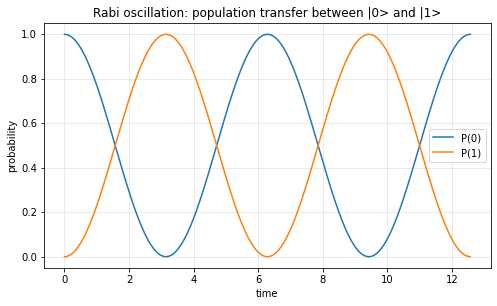

For Omega = 1,
the first pi-pulse time is
t_pi = pi/Omega = 3.141592653589793


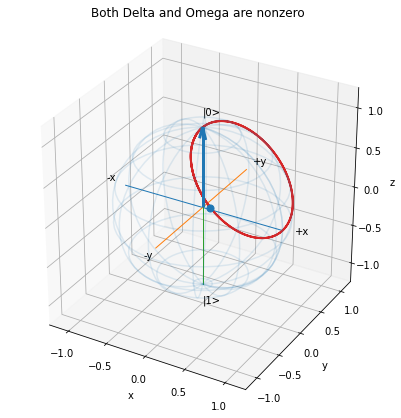

In [3]:
# ============================================================
# QUESTION
# ============================================================

# We started at |0>.
#
# The Hamiltonian is now:
#
#       0       Omega/2
# H = [
#       Omega/2    0
#     ]
#
#
# Is population transferred between |0> and |1>?
#
# Which axis does the Bloch vector rotate around?

# ============================================================
# 9) Population transfer / Rabi oscillation
# ============================================================

# Now start at |0> and turn on only off-diagonal coupling.
#
# This should transfer probability between |0> and |1>.

Delta = 0.0
Omega = 1.0

H = hamiltonian(Delta, Omega)

psi0 = zero

tlist = np.linspace(
    0,
    4 * np.pi,
    400
)


P0 = []
P1 = []


for t in tlist:

    psi_t = evolve(H, psi0, t)

    # Probability of being in |0>
    #
    # P0 = |<0|psi>|^2

    p0 = np.abs(np.vdot(zero, psi_t))**2


    # Probability of being in |1>
    #
    # P1 = |<1|psi>|^2

    p1 = np.abs(np.vdot(one, psi_t))**2


    P0.append(p0)
    P1.append(p1)


P0 = np.array(P0)
P1 = np.array(P1)


plt.figure(figsize=(8, 4.5))

plt.plot(tlist, P0, label="P(0)")

plt.plot(tlist, P1, label="P(1)")

plt.xlabel("time")
plt.ylabel("probability")

plt.title("Rabi oscillation: population transfer between |0> and |1>")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


print("For Omega = 1,")

print("the first pi-pulse time is")

print("t_pi = pi/Omega =",np.pi / Omega)


# ============================================================
# 10) Change Omega
# ============================================================

# Try:
#
# Omega = 0.5
#
# Omega = 1.0
#
# Omega = 2.0
#
#
# QUESTION:
# What happens to the Rabi oscillation when Omega increases?
#
#
# Does the qubit:
#
# A) rotate faster
# B) rotate slower
# C) stay unchanged
#
#
# Can you predict t_pi before running the code?


# ============================================================
# 11) Both diagonal AND off-diagonal terms
# ============================================================

Delta = 1.0
Omega = 1.0

H = hamiltonian(
    Delta,
    Omega
)

psi0 = zero

tlist, x, y, z = run_dynamics(
    psi0,
    H,
    tmax=10,
    nt=400
)

show_bloch_trajectory(
    x,
    y,
    z,
    title="Both Delta and Omega are nonzero"
)


# ============================================================
# QUESTION
# ============================================================

# When Delta = 0 and Omega != 0,
# the rotation axis is x.
#
#
# When Delta != 0 and Omega = 0,
# the rotation axis is z.
#
#
# So what do you expect when BOTH are nonzero?
#
#
# Look at the trajectory.
#
# Is the rotation axis still x?
#
# Is it still z?
#
# Or is it tilted between them?


# ============================================================
# Student questions / challenges
# ============================================================

# 1.
# What theta and phi produce:
#
# |0>
# |1>
# +x
# +y
# -x
# -y
#
#
# 2.
# What happens if Delta is nonzero
# but Omega = 0?
#
#
# 3.
# What happens if Omega is nonzero
# but Delta = 0?
#
#
# 4.
# What happens when Delta and Omega
# are both nonzero?
#
#
# 5.
# If Omega doubles,
# what happens to the Rabi oscillation period?
#
#
# 6.
# Can you find the first time
# where P(1) = 1?
#
#
# 7.
# Start from +x:
#
# psi0 = state_from_angles(np.pi/2, 0)
#
# and use
#
# Delta = 0
# Omega = 1
#
# What happens?
#
# Why does the state behave differently
# from a qubit starting at |0>?
#
#
# 8. BONUS:
#
# Try
#
# Delta = 3
# Omega = 1
#
# starting from |0>.
#
# Does the qubit still reach |1> perfectly?
#
# Why might a large diagonal term make
# population transfer less effective?